# Phase 3.5: 回测绩效分析与多进程参数寻优可视化大盘

本 Notebook 展示了对系统内双均线策略在白银高频历史分钟线上的回测结果。主要包含以下部分：
1. **历史回测运行**：从本地数据库拉取白银数据，加载策略跑通回测。
2. **回测绩效指标计算**：计算年化收益率、最大回撤、夏普比率、索提诺比率、胜率等。
3. **专业图表可视化**：使用 `matplotlib` 绘制**资金曲线**、**回撤变化**以及 **K 线买卖信号标记图**。
4. **多进程参数网格搜索**：并发寻优最佳参数组合。

## 1. 准备工作与数据回测运行

In [1]:
import sys
import os
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

# 确保项目根目录在导入路径中
sys.path.insert(0, os.path.abspath('.'))
load_dotenv()

from data.db_manager import DBManager
from backtest.backtester import CtaBacktester
from strategy.strategies.double_ma_strategy import DoubleMaStrategy
from backtest.analysis import calculate_statistics
from backtest.optimizer import run_grid_search
from core.models import Direction, Offset

# 1. 连接数据库
db_name = os.getenv("PG_DBNAME_PROD", "quant_db_prod") # 使用生产库
db_user = os.getenv("PG_USER", "postgres")
db_pass = os.getenv("PG_PASSWORD", "")
db_host = os.getenv("PG_HOST", "localhost")
db_port = os.getenv("PG_PORT", "5432")

db = DBManager(dbname=db_name, user=db_user, password=db_pass, host=db_host, port=db_port)
print(f"✅ 成功连接数据库: {db_name}")

# 2. 初始化回测引擎
backtester = CtaBacktester(db)

# 寻找数据库中已有的合约数据
# 白银主力连续 AG88
symbol = "AG88"
exchange = "SHF"
interval = "1m"
start_date = datetime(2026, 1, 1)
end_date = datetime(2026, 7, 1)

backtester.load_data(symbol, exchange, interval, start_date, end_date)

if not backtester.bars:
    print(f"⚠️ 警告: 数据库中没有 {symbol}.{exchange} 在该时间段的数据。")
    # 自动降低要求，查询全部数据中最大时间，并向前取30天进行测试
    max_dt = db.get_max_datetime(symbol, exchange, interval)
    if max_dt:
        start_date = max_dt - timedelta(days=30)
        end_date = max_dt
        print(f"🔄 自动对齐到最新数据时段: {start_date} 至 {end_date}")
        backtester.load_data(symbol, exchange, interval, start_date, end_date)
    else:
        print("❌ 数据库为空！请先从天勤或米筐运行脚本下载历史数据到本地数据库中。")

✅ 成功连接数据库: quant_db_prod
开始从数据库加载历史数据: AG88.SHF [2026-01-01 00:00:00 到 2026-07-01 00:00:00]


数据加载完成，共计 62910 根 K 线


## 2. 运行双均线策略回测

In [2]:
if backtester.bars:
    # 绑定策略：快线 10，慢线 30
    backtester.set_strategy(DoubleMaStrategy, "DoubleMa_Demo", f"{symbol}.{exchange}", {"fast_window": 10, "slow_window": 30})
    backtester.run_backtest()
    print(f"回测完成，共产生 {len(backtester.trades)} 笔交易。")

策略 DoubleMaStrategy 已加载
开始回测...
[None] DoubleMa_Demo: 策略初始化
[None] DoubleMa_Demo: 策略启动
[2026-01-08 09:01:00] DoubleMa_Demo: 成交回报: 空 开 1手 @ 19020.0。当前持仓：-1
[2026-01-09 23:59:00] DoubleMa_Demo: 成交回报: 多 平 1手 @ 19617.0。当前持仓：0
[2026-01-09 23:59:00] DoubleMa_Demo: 成交回报: 多 开 1手 @ 19617.0。当前持仓：1
[2026-01-16 00:59:00] DoubleMa_Demo: 成交回报: 空 平 1手 @ 22825.0。当前持仓：0
[2026-01-16 00:59:00] DoubleMa_Demo: 成交回报: 空 开 1手 @ 22825.0。当前持仓：-1
[2026-01-16 09:59:00] DoubleMa_Demo: 成交回报: 多 平 1手 @ 22865.0。当前持仓：0
[2026-01-16 09:59:00] DoubleMa_Demo: 成交回报: 多 开 1手 @ 22865.0。当前持仓：1
[2026-01-16 21:01:00] DoubleMa_Demo: 成交回报: 空 平 1手 @ 22483.0。当前持仓：0
[2026-01-16 21:01:00] DoubleMa_Demo: 成交回报: 空 开 1手 @ 22483.0。当前持仓：-1
[2026-01-19 21:01:00] DoubleMa_Demo: 成交回报: 多 平 1手 @ 23189.0。当前持仓：0
[2026-01-19 21:01:00] DoubleMa_Demo: 成交回报: 多 开 1手 @ 23189.0。当前持仓：1
[2026-01-21 13:59:00] DoubleMa_Demo: 成交回报: 空 平 1手 @ 23170.0。当前持仓：0
[2026-01-21 13:59:00] DoubleMa_Demo: 成交回报: 空 开 1手 @ 23170.0。当前持仓：-1
[2026-01-22 21:01:00] DoubleMa_Demo: 成

## 3. 计算绩效指标报告

In [3]:
if backtester.bars and backtester.trades:
    # 计算绩效统计
    stats = calculate_statistics(backtester.trades, backtester.bars, start_capital=1000000.0, volume_multiple=15)
    
    # 打印排版整齐的报告
    print("="*45)
    print(f"📊 【回测绩效报告】 {symbol}.{exchange} ")
    print("="*45)
    print(f" 初始资金:      {stats['start_capital']:,.2f} 元")
    print(f" 期末权益:      {stats['end_equity']:,.2f} 元")
    print(f" 总收益率:      {stats['total_return']*100:.2f}%")
    print(f" 年化收益率:    {stats['annualized_return']*100:.2f}%")
    print(f" 最大回撤:      {stats['max_drawdown']*100:.2f}%")
    print(f" 夏普比率:      {stats['sharpe_ratio']:.2f}")
    print(f" 索提诺比率:    {stats['sortino_ratio']:.2f}")
    print(f" 总交易笔数:    {stats['total_trades']} 笔")
    print(f" 胜率:          {stats['win_rate']*100:.2f}%")
    print(f" 盈亏比:        {stats['profit_loss_ratio']:.2f}")
    print(f" 累计手续费:    {stats['total_commission']:,.2f} 元")
    print("="*45)
else:
    print("由于数据或成交为空，跳过绩效统计")

📊 【回测绩效报告】 AG88.SHF 
 初始资金:      1,000,000.00 元
 期末权益:      1,166,311.01 元
 总收益率:      16.63%
 年化收益率:    29.13%
 最大回撤:      -16.01%
 夏普比率:      1.55
 索提诺比率:    2.37
 总交易笔数:    45 笔
 胜率:          35.56%
 盈亏比:        2.87
 累计手续费:    2,693.99 元


## 4. 回测可视化大图展示

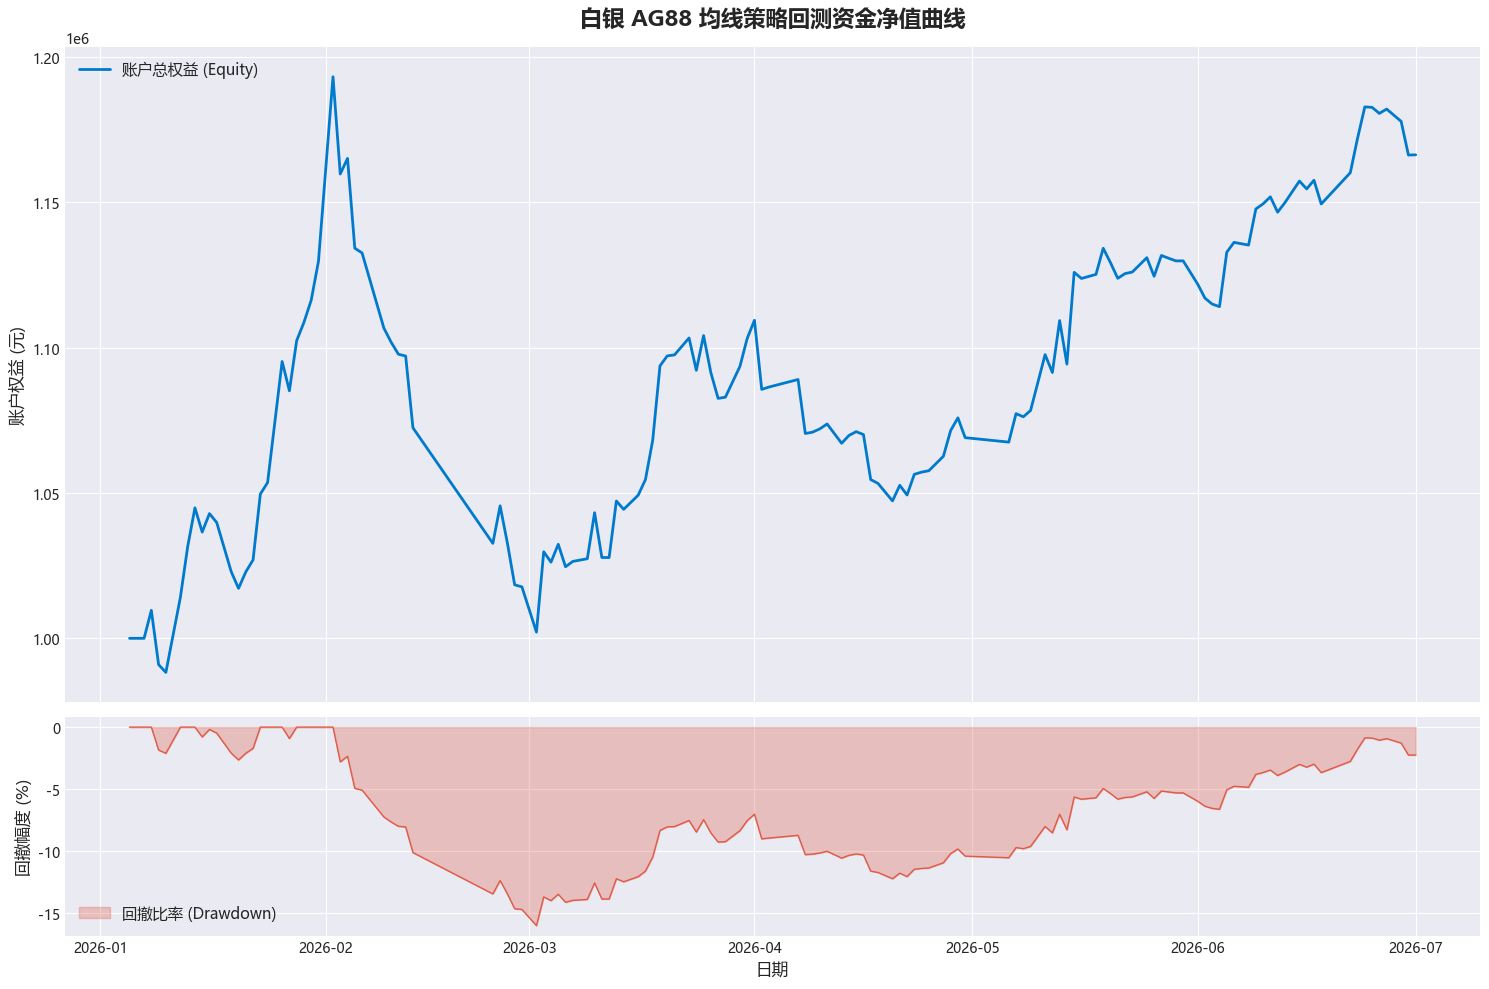

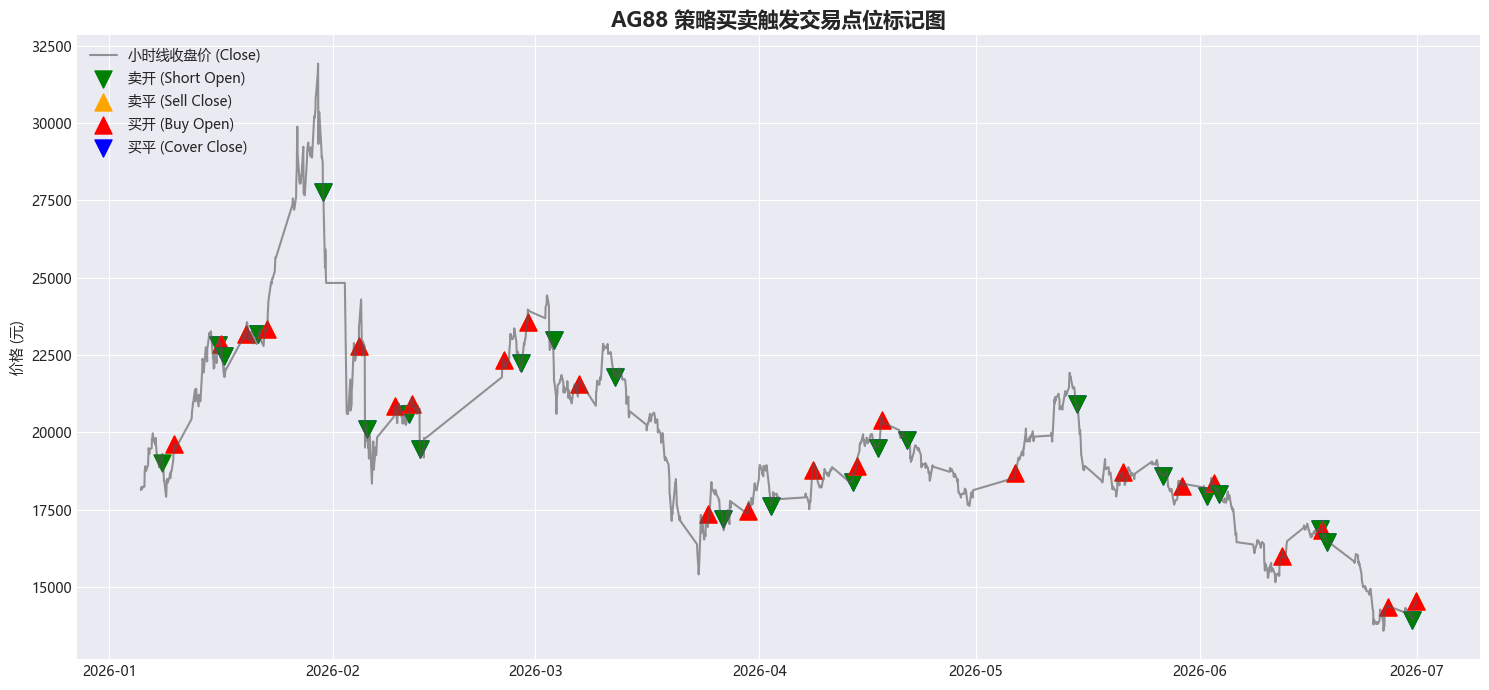

In [4]:
if backtester.bars and backtester.trades:
    # 设置中文字体与绘图风格
    plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'STHeiti', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False
    
    df_d = stats["daily_equity"]
    
    # 图 1: 权益曲线与回撤走势
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(df_d["date"], df_d["equity"], color="#007acc", linewidth=2, label="账户总权益 (Equity)")
    ax1.set_title(f"白银 {symbol} 均线策略回测资金净值曲线", fontsize=16, fontweight='bold', pad=15)
    ax1.set_ylabel("账户权益 (元)", fontsize=12)
    ax1.legend(loc="upper left", fontsize=11)
    
    ax2.fill_between(df_d["date"], df_d["drawdown"] * 100, 0, color="#e05a47", alpha=0.3, label="回撤比率 (Drawdown)")
    ax2.plot(df_d["date"], df_d["drawdown"] * 100, color="#e05a47", linewidth=1)
    ax2.set_ylabel("回撤幅度 (%)", fontsize=12)
    ax2.set_xlabel("日期", fontsize=12)
    ax2.legend(loc="lower left", fontsize=11)
    
    plt.tight_layout()
    plt.show()

    # 图 2: 策略买卖点标记图
    # 提取策略自己记录的 60m 历史 K 线
    history_bars = backtester.strategy.history_bars
    if history_bars:
        k_data = []
        for hb in history_bars:
            k_data.append({"datetime": hb.datetime, "close": hb.close_price})
        df_k = pd.DataFrame(k_data).sort_values("datetime").reset_index(drop=True)
        
        plt.figure(figsize=(15, 7))
        plt.plot(df_k["datetime"], df_k["close"], color="#555555", alpha=0.6, label="小时线收盘价 (Close)")
        
        # 绘制成交买卖点
        # 匹配最接近的 60m K 线时间点进行标记
        for t in backtester.trades:
            # 寻找时间戳最接近的 60m 节点
            diffs = np.abs((df_k["datetime"] - t.datetime).dt.total_seconds())
            closest_idx = diffs.idxmin()
            trade_dt = df_k.loc[closest_idx, "datetime"]
            trade_price = t.price
            
            # 根据买卖开平类型设置箭头和颜色
            if t.direction == Direction.LONG and t.offset == Offset.OPEN:
                plt.scatter(trade_dt, trade_price, color="red", marker="^", s=150, label="买开 (Buy Open)" if "买开 (Buy Open)" not in plt.gca().get_legend_handles_labels()[1] else "")
            elif t.direction == Direction.SHORT and t.offset == Offset.CLOSE:
                plt.scatter(trade_dt, trade_price, color="blue", marker="v", s=150, label="买平 (Cover Close)" if "买平 (Cover Close)" not in plt.gca().get_legend_handles_labels()[1] else "")
            elif t.direction == Direction.SHORT and t.offset == Offset.OPEN:
                plt.scatter(trade_dt, trade_price, color="green", marker="v", s=150, label="卖开 (Short Open)" if "卖开 (Short Open)" not in plt.gca().get_legend_handles_labels()[1] else "")
            elif t.direction == Direction.LONG and t.offset == Offset.CLOSE:
                plt.scatter(trade_dt, trade_price, color="orange", marker="^", s=150, label="卖平 (Sell Close)" if "卖平 (Sell Close)" not in plt.gca().get_legend_handles_labels()[1] else "")
                
        plt.title(f"{symbol} 策略买卖触发交易点位标记图", fontsize=15, fontweight='bold')
        plt.ylabel("价格 (元)")
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

## 5. 多进程参数网格寻优

In [5]:
if backtester.bars:
    # 准备寻优参数配置
    db_conn_info = {
        "dbname": db_name,
        "user": db_user,
        "password": db_pass,
        "host": db_host,
        "port": int(db_port)
    }
    
    grid = {
        "fast_window": [5, 10, 15],
        "slow_window": [20, 30, 40]
    }
    
    # 并发执行参数搜索
    results = run_grid_search(
        strategy_class=DoubleMaStrategy,
        db_conn_info=db_conn_info,
        symbol=symbol,
        exchange=exchange,
        interval=interval,
        start=start_date,
        end=end_date,
        parameter_grid=grid,
        processes=2  # 并行进程数
    )
    
    # 打印排前 5 名的最佳参数组
    print("\n🧬 【网格寻优结果排序 (前5名)】")
    print("-"*65)
    print(f"{'排名':^4} | {'参数组合':<22} | {'夏普比率':^8} | {'总收益率':^8} | {'最大回撤':^8}")
    print("-"*65)
    for idx, r in enumerate(results[:5]):
        print(f" {idx+1:^4} | {str(r['setting']):<22} | {r['sharpe_ratio']:^8.2f} | {r['total_return']*100:^7.1f}% | {r['max_drawdown']*100:^7.1f}%")
    print("-"*65)
    
    db.close() # 关闭主数据库连接

🧬 启动多进程网格寻优，进程数: 2
标的: AG88.SHF | 区间: 2026-01-01 至 2026-07-01
🔥 参数展开成功，共计 9 组参数待回测


 [1/9] 参数 {'fast_window': 5, 'slow_window': 20} => 夏普: 2.16 | 收益率: 16.5%
 [2/9] 参数 {'fast_window': 5, 'slow_window': 30} => 夏普: 2.22 | 收益率: 16.5%


 [3/9] 参数 {'fast_window': 10, 'slow_window': 20} => 夏普: 1.05 | 收益率: 7.7%
 [4/9] 参数 {'fast_window': 5, 'slow_window': 40} => 夏普: 1.25 | 收益率: 9.3%


 [5/9] 参数 {'fast_window': 10, 'slow_window': 30} => 夏普: 1.52 | 收益率: 11.1%
 [6/9] 参数 {'fast_window': 10, 'slow_window': 40} => 夏普: 0.87 | 收益率: 6.2%


 [7/9] 参数 {'fast_window': 15, 'slow_window': 20} => 夏普: 0.12 | 收益率: 0.4%
 [8/9] 参数 {'fast_window': 15, 'slow_window': 30} => 夏普: 0.03 | 收益率: -0.3%


 [9/9] 参数 {'fast_window': 15, 'slow_window': 40} => 夏普: 0.32 | 收益率: 2.0%

🧬 【网格寻优结果排序 (前5名)】
-----------------------------------------------------------------
 排名  | 参数组合                   |   夏普比率   |   总收益率   |   最大回撤  
-----------------------------------------------------------------
  1   | {'fast_window': 5, 'slow_window': 30} |   2.22   |  16.5  % |  -7.8  %
  2   | {'fast_window': 5, 'slow_window': 20} |   2.16   |  16.5  % |  -4.5  %
  3   | {'fast_window': 10, 'slow_window': 30} |   1.52   |  11.1  % |  -11.3 %
  4   | {'fast_window': 5, 'slow_window': 40} |   1.25   |   9.3  % |  -10.8 %
  5   | {'fast_window': 10, 'slow_window': 20} |   1.05   |   7.7  % |  -8.9  %
-----------------------------------------------------------------
